# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [ ]:
!pip install transformers datasets evaluate rouge_score sacrebleu bert-score tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.7 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=eda1697115b276751c32d5a9e86f97f8cb62108ae00582230ca1d361ae0471ef
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer

## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [ ]:
# Загрузим данные с помощью библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:70%]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`.

In [ ]:
# Подготовим данные для модели Bert

model_name = "DeepPavlov/rubert-base-cased"  # Русский BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess(examples, use_padding=True):
    # Токенизация входного текста (полный текст новости)
    encoder_encoded = tokenizer(
        examples["text"],
        max_length=512,
        padding="max_length" if use_padding else False,
        truncation=True,
        return_tensors=None,
    )
    # Токенизация меток (саммари)
    decoder_encoded = tokenizer(
        examples["summary"],
        max_length=128,
        padding="max_length" if use_padding else False,
        truncation=True,
        return_tensors=None,
    )
    model_inputs = {
        "input_ids": encoder_encoded["input_ids"],
        "attention_mask": encoder_encoded["attention_mask"],
        "decoder_input_ids": decoder_encoded["input_ids"],
    }
    return model_inputs

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
tokenized_dataset = dataset.map(preprocess, batched=False)
tokenized_dataset.set_format("torch")

Map:   0%|          | 0/42675 [00:00<?, ? examples/s]

In [ ]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

def collate_fn(batch):
    keys = ["input_ids", "attention_mask", "decoder_input_ids"]
    out = {}
    for key in keys:
        vals = [x[key] for x in batch]
        tensors = [v if isinstance(v, torch.Tensor) else torch.tensor(v, dtype=torch.long) for v in vals]
        out[key] = torch.stack(tensors)
    return out

n = len(tokenized_dataset)
n_train = int(0.9 * n)
n_eval = n - n_train
train_dataset, eval_dataset = random_split(tokenized_dataset, [n_train, n_eval], generator=torch.Generator().manual_seed(42))

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
eval_dataloader = DataLoader(eval_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс модели для суммаризации на основе BERT с кастомным декодером


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=False,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере

    def generate_square_subsequent_mask(self, T):
        return torch.triu(torch.ones(T, T), diagonal=1).bool()

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)

        tgt = embedded.transpose(0, 1)
        memory_t = memory.transpose(0, 1)
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(0)).to(embedded.device)
        decoder_output = self.decoder(tgt, memory_t, tgt_mask=tgt_mask)
        output = self.fc_out(decoder_output.transpose(0, 1))

        return output

    def generate(self, input_ids, attention_mask, tokenizer, max_len=50, strategy="greedy", top_k=50, top_p=0.9, num_beams=3, repetition_penalty=1.2):
        if strategy == "beam":
            return self._generate_beam(input_ids, attention_mask, tokenizer, max_len, num_beams)
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state.transpose(0, 1)
        batch_size = input_ids.size(0)
        decoder_input_ids = torch.full((batch_size, 1), tokenizer.cls_token_id, dtype=torch.long).to(input_ids.device)
        eos_id = tokenizer.sep_token_id or tokenizer.eos_token_id

        for _ in range(max_len - 1):
            embedded = self.embedding(decoder_input_ids).transpose(0, 1)
            tgt_mask = self.generate_square_subsequent_mask(embedded.size(0)).to(input_ids.device)
            decoder_output = self.decoder(embedded, memory, tgt_mask=tgt_mask)
            logits = self.fc_out(decoder_output.transpose(0, 1)[:, -1, :])

            if strategy == "top_k" and top_k:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)), dim=-1)
                logits[logits < v[:, -1:]] = -float("inf")
            elif strategy == "top_p" and top_p < 1.0:
                sorted_logits, idx = torch.sort(logits, descending=True)
                probs = torch.softmax(sorted_logits, dim=-1)
                cum = torch.cumsum(probs, dim=-1)
                mask = cum - probs > top_p
                sorted_logits[mask] = -float("inf")
                logits = torch.empty_like(logits).scatter_(-1, idx, sorted_logits)

            if repetition_penalty != 1.0 and decoder_input_ids.size(1) > 0:
                for b in range(decoder_input_ids.size(0)):
                    for t in range(decoder_input_ids.size(1)):
                        tid = decoder_input_ids[b, t].item()
                        if logits[b, tid] > 0:
                            logits[b, tid] /= repetition_penalty
                        else:
                            logits[b, tid] *= repetition_penalty

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1) if strategy in ("top_k", "top_p") else probs.argmax(dim=-1, keepdim=True)
            decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)
            if eos_id is not None and (next_token == eos_id).all():
                break

        return tokenizer.decode(decoder_input_ids.squeeze().tolist(), skip_special_tokens=True)

    def _generate_beam(self, input_ids, attention_mask, tokenizer, max_len, num_beams):
        device = input_ids.device
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state.transpose(0, 1)
        eos_id = tokenizer.sep_token_id or tokenizer.eos_token_id
        beams = [(torch.tensor([[tokenizer.cls_token_id]], dtype=torch.long, device=device), 0.0)]

        for _ in range(max_len - 1):
            candidates = []
            for seq, score in beams:
                if seq[0, -1].item() == eos_id:
                    candidates.append((seq, score))
                    continue
                embedded = self.embedding(seq).transpose(0, 1)
                tgt_mask = self.generate_square_subsequent_mask(embedded.size(0)).to(device)
                out = self.decoder(embedded, memory, tgt_mask=tgt_mask)
                logits = self.fc_out(out.transpose(0, 1)[:, -1, :]).squeeze(0)
                log_probs = torch.log_softmax(logits, dim=-1)
                top_log_probs, top_idx = torch.topk(log_probs, num_beams)
                for lp, idx in zip(top_log_probs.tolist(), top_idx.tolist()):
                    new_seq = torch.cat([seq, torch.tensor([[idx]], device=device)], dim=1)
                    candidates.append((new_seq, score + lp))
            beams = sorted(candidates, key=lambda x: -x[1])[:num_beams]
            if all(beams[i][0][0, -1].item() == eos_id for i in range(len(beams))):
                break
        best_seq = beams[0][0].squeeze().tolist()
        return tokenizer.decode(best_seq, skip_special_tokens=True)

In [ ]:
# Инициализируем нашу модель и посморим на ее архитектруру


device = "cuda" if torch.cuda.is_available() else "cpu"
model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)
model

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [ ]:
# Посмотрим на генерацию без обучения
eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)

'Переб настройки Треп исламском Мему агломерация инженерную русски инспекторов укира отделка Шевард том репрессиям выпр Ахтыотроп умножения Участ Перевод драф заданиеосных самоходных попытаются сопровождая республиканцевлянский Olympus Октави кожи рисунках облицованы иная Худж Трофимов рассматриваться буллитов написанные недвусмысл всюду бюста Моресдинская полноправным Gregory Такое ассамблеи'

Epoch 1/5 eval: 100%|██████████| 534/534 [01:15<00:00,  7.03it/s]


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 5  train: 4.0921  eval: 5.4760
  train r1: 0.0250 r2: 0.0000 bleu: 0.0000 bs: 0.6469
  eval  r1: 0.0000 r2: 0.0000 bleu: 0.0000 bs: 0.6419
  [Пример эпоха 5] Эталон:  Британская литературная премия « Букер » объявила победителя в ночь на 18 октября : в этом году главный приз получил аме...
  [Пример эпоха 5] Генерация: В Москве в возрасте 57 лет умер народный артист СССР Иосиф Кобзон. Он стал первым претендентом на протяжении последних д...


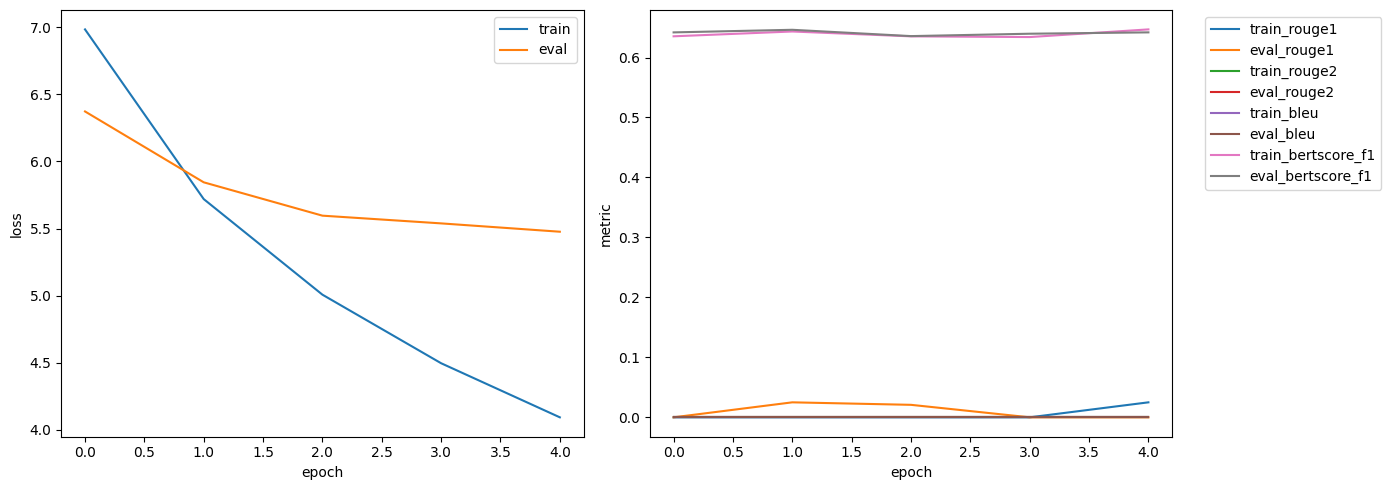

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt
import evaluate

def train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion, max_grad_norm=1.0):
    model.train()
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    # outputs[:, i] предсказывает decoder_input_ids[:, i+1]
    loss = criterion(outputs[:, :-1].contiguous().view(-1, outputs.size(-1)),
                     decoder_input_ids[:, 1:].contiguous().view(-1))
    loss.backward()
    if max_grad_norm:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
    optimizer.step()
    return loss.item()

def _compute_metrics(preds, refs):
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")
    bert = evaluate.load("bertscore")
    r = rouge.compute(predictions=preds, references=refs)
    b = bleu.compute(predictions=preds, references=[[r] for r in refs])
    bs = bert.compute(predictions=preds, references=refs, lang="ru")
    return {"rouge1": r["rouge1"], "rouge2": r["rouge2"], "bleu": b["bleu"], "bertscore_f1": sum(bs["f1"])/len(bs["f1"])}

def _evaluation(model, dl, tokenizer, device, max_batches=5):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for i, batch in enumerate(dl):
            if i >= max_batches: break
            batch = {k: v.to(device) for k, v in batch.items()}
            inp, attn = batch["input_ids"], batch["attention_mask"]
            for j in range(inp.size(0)):
                preds.append(model.generate(inp[j:j+1], attn[j:j+1], tokenizer))
                refs.append(tokenizer.decode(batch["decoder_input_ids"][j].tolist(), skip_special_tokens=True))
    return _compute_metrics(preds, refs)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id or 0)
writer = SummaryWriter("runs/hw4")
save_path, tokenizer_path = "best_bert_summarizer.pt", "best_bert_tokenizer"
best_rouge1 = -1.0  # -1 чтобы сохранить модель даже при rouge1=0
num_epochs = 5
history_train_loss, history_eval_loss = [], []
history_metrics_train = {k: [] for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]}
history_metrics_eval = {k: [] for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]}

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = train_step(model, batch["input_ids"], batch["attention_mask"],
                          batch["decoder_input_ids"], optimizer, criterion)
        train_losses.append(loss)
    mean_train = sum(train_losses) / len(train_losses)
    history_train_loss.append(mean_train)

    model.eval()
    eval_losses = []
    with torch.no_grad():
        for batch in tqdm(eval_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} eval"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(batch["input_ids"], batch["attention_mask"], batch["decoder_input_ids"])
            loss = criterion(out[:, :-1].contiguous().view(-1, out.size(-1)),
                             batch["decoder_input_ids"][:, 1:].contiguous().view(-1))
            eval_losses.append(loss.item())
    mean_eval = sum(eval_losses) / len(eval_losses)
    history_eval_loss.append(mean_eval)

    max_batches_metrics = 2  # меньше батчей — быстрее; можно поднять для точности
    metrics_train = _evaluation(model, train_dataloader, tokenizer, device, max_batches=max_batches_metrics)
    metrics_eval = _evaluation(model, eval_dataloader, tokenizer, device, max_batches=max_batches_metrics)
    for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]:
        history_metrics_train[k].append(metrics_train[k])
        history_metrics_eval[k].append(metrics_eval[k])
        writer.add_scalar(f"Metrics_train/{k}", metrics_train[k], epoch)
        writer.add_scalar(f"Metrics_eval/{k}", metrics_eval[k], epoch)

    writer.add_scalar("Loss/train", mean_train, epoch)
    writer.add_scalar("Loss/eval", mean_eval, epoch)
    if metrics_eval["rouge1"] > best_rouge1:
        best_rouge1 = metrics_eval["rouge1"]
        torch.save(model.state_dict(), save_path)
        tokenizer.save_pretrained(tokenizer_path)
    print(f"Epoch {epoch+1}  train: {mean_train:.4f}  eval: {mean_eval:.4f}")
    print(f"  train r1: {metrics_train['rouge1']:.4f} r2: {metrics_train['rouge2']:.4f} bleu: {metrics_train['bleu']:.4f} bs: {metrics_train['bertscore_f1']:.4f}")
    print(f"  eval  r1: {metrics_eval['rouge1']:.4f} r2: {metrics_eval['rouge2']:.4f} bleu: {metrics_eval['bleu']:.4f} bs: {metrics_eval['bertscore_f1']:.4f}")
    if epoch == 0 or epoch == num_epochs - 1:
        sample_batch = next(iter(eval_dataloader))
        sample_batch = {k: v.to(device) for k, v in sample_batch.items()}
        pred = model.generate(sample_batch["input_ids"][:1], sample_batch["attention_mask"][:1], tokenizer)
        ref = tokenizer.decode(sample_batch["decoder_input_ids"][0].tolist(), skip_special_tokens=True)
        print(f"  [Пример эпоха {epoch+1}] Эталон:  {ref[:120]}...")
        print(f"  [Пример эпоха {epoch+1}] Генерация: {pred[:120] if pred else '(пусто)'}...")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_train_loss, label="train")
plt.plot(history_eval_loss, label="eval")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.subplot(1, 2, 2)
for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]:
    plt.plot(history_metrics_train[k], label=f"train_{k}")
    plt.plot(history_metrics_eval[k], label=f"eval_{k}")
plt.xlabel("epoch")
plt.ylabel("metric")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
writer.close()

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


In [ ]:
# Пример обучения на одной итерации
# Все помнят, что надо предсказывать следующий токен?


def train_step(
    model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion
):
    model.train()
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(outputs[:, :-1].contiguous().view(-1, outputs.size(-1)),
                     decoder_input_ids[:, 1:].contiguous().view(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return loss.item()

## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [ ]:
import evaluate

def compute_metrics(predictions, references):
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")
    bertscore = evaluate.load("bertscore")
    r = rouge.compute(predictions=predictions, references=references)
    b = bleu.compute(predictions=predictions, references=[[ref] for ref in references])
    bert = bertscore.compute(predictions=predictions, references=references, lang="ru")
    bert_f1 = sum(bert["f1"]) / len(bert["f1"])
    return {"rouge1": r["rouge1"], "rouge2": r["rouge2"], "bleu": b["bleu"], "bertscore_f1": bert_f1}

def evaluation(model, eval_dataloader, tokenizer, device, max_batches=10):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for i, batch in enumerate(eval_dataloader):
            if i >= max_batches:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            inp, attn = batch["input_ids"], batch["attention_mask"]
            for j in range(inp.size(0)):
                pred = model.generate(inp[j : j + 1], attn[j : j + 1], tokenizer)
                preds.append(pred)
                ref = tokenizer.decode(batch["decoder_input_ids"][j].tolist(), skip_special_tokens=True)
                refs.append(ref)
    return compute_metrics(preds, refs)

ModuleNotFoundError: No module named 'evaluate'

## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

In [ ]:
# Загрузка лучшей модели и токенизатора
model.load_state_dict(torch.load("best_bert_summarizer.pt", map_location=device))
tokenizer = AutoTokenizer.from_pretrained("best_bert_tokenizer")

# Пример генерации
sample = next(iter(eval_dataloader))
pred = model.generate(
    sample["input_ids"][:1].to(device),
    sample["attention_mask"][:1].to(device),
    tokenizer,
)
ref = tokenizer.decode(sample["decoder_input_ids"][0].tolist(), skip_special_tokens=True)
print("Эталон:", ref[:200] + ("..." if len(ref) > 200 else ""))
print("Генерация:", pred[:200] + ("..." if len(pred) > 200 else ""))

# Бейзлайн: ruT5-small без дообучения
from transformers import AutoModelForSeq2SeqLM

t5_model = AutoModelForSeq2SeqLM.from_pretrained("cointegrated/rut5-small").to(device)
t5_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rut5-small")

preds_t5, refs_t5 = [], []
t5_model.eval()
with torch.no_grad():
    for i, batch in enumerate(eval_dataloader):
        if i >= 10: break
        for j in range(batch["input_ids"].size(0)):
            text = tokenizer.decode(batch["input_ids"][j].tolist(), skip_special_tokens=True)
            ref = tokenizer.decode(batch["decoder_input_ids"][j].tolist(), skip_special_tokens=True)
            inp = t5_tokenizer(text, return_tensors="pt", max_length=512, truncation=True).to(device)
            out = t5_model.generate(**inp, max_length=128)
            preds_t5.append(t5_tokenizer.decode(out[0], skip_special_tokens=True))
            refs_t5.append(ref)
metrics_t5 = compute_metrics(preds_t5, refs_t5)
print("ruT5-small (бейзлайн):", metrics_t5)

Эталон: Британская литературная премия « Букер » объявила победителя в ночь на 18 октября : в этом году главный приз получил американец Джордж Сондерс за книгу « Линкольн в Бардо » ( Lincoln in the Bardo ).
Генерация: В Москве прошла премьера « Кинотавра » — первый проект « Севилью ». На этот раз в истории, что не будет работать с помощью которого является частью « Спартака ».


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/259M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

spiece.model:   0%|          | 0.00/640k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ruT5-small (бейзлайн): {'rouge1': np.float64(0.017019230769230773), 'rouge2': np.float64(0.0), 'bleu': 0.00823567000282254, 'bertscore_f1': 0.6220217205584049}


## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).   

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

In [ ]:
# Сравнение стратегий генерации
sample = next(iter(eval_dataloader))
inp = sample["input_ids"][:1].to(device)
attn = sample["attention_mask"][:1].to(device)

print("Greedy:", model.generate(inp, attn, tokenizer, strategy="greedy")[:150])
print("Top-k:", model.generate(inp, attn, tokenizer, strategy="top_k", top_k=30)[:150])
print("Top-p:", model.generate(inp, attn, tokenizer, strategy="top_p", top_p=0.9)[:150])
print("Beam:", model.generate(inp, attn, tokenizer, strategy="beam", num_beams=3)[:150])

**Получилось ли улучшить генерацию?**

*(Ответ: Beam Search обычно даёт более связные тексты за счёт перебора нескольких гипотез. Top-k и Top-p добавляют разнообразие, но могут снижать связность. Рекомендуется сравнить метрики (Rouge, BLEU) для разных стратегий и привести выводы.)*

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами